In [ ]:
from environment import Environment
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
import numpy as np
import os
os.chdir(os.path.dirname(os.getcwd()))

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

N = 200000
BATCH_SIZE = 10000

for warning in []:  # ['yellow', 'amber', 'red']
    print(warning)
    csv_path = f"warning/samples/{warning}_samples.csv"
    environment = Environment(use_historic=warning)
    header_written = False # Always start fresh
    first_batch = True # Track whether to overwrite or append

    batch = defaultdict(list)

    for i in range(N):
        # --------------- Sampling
        environment.sample_features()
        environment.update_derived()

        # --------------- Saving samples
        for key, value in environment.samples.features.items():
            if key not in ("season", "geometry"):
                batch[key].append(value)

        for key, value in environment.derived.items():
            batch[key].append(value)

        batch["impact"].append(environment.impact)

        # Flush to disk every BATCH_SIZE iterations
        if (i + 1) % BATCH_SIZE == 0:
            print(f"Batch {(i + 1) // BATCH_SIZE}")
            df = pd.DataFrame(batch)
            df.to_csv(csv_path, mode="w" if first_batch else "a", index=False, header=not header_written)
            header_written = True
            first_batch = False
            batch = defaultdict(list)

    # Write any remaining rows
    if batch:
        df = pd.DataFrame(batch)
        df.to_csv(csv_path, mode="w" if first_batch else "a", index=False, header=not header_written)

yellow
Batch 1
Batch 2
Batch 3
Batch 4
Batch 5
Batch 6
Batch 7
Batch 8
Batch 9
Batch 10
Batch 11
Batch 12
Batch 13
Batch 14
Batch 15
Batch 16
Batch 17
Batch 18
Batch 19
Batch 20


In [5]:
df = pd.read_csv("warning/samples/red_samples.csv")
duplicates = df.duplicated()
print(f"Duplicate rows: {duplicates.sum()}")

Duplicate rows: 0


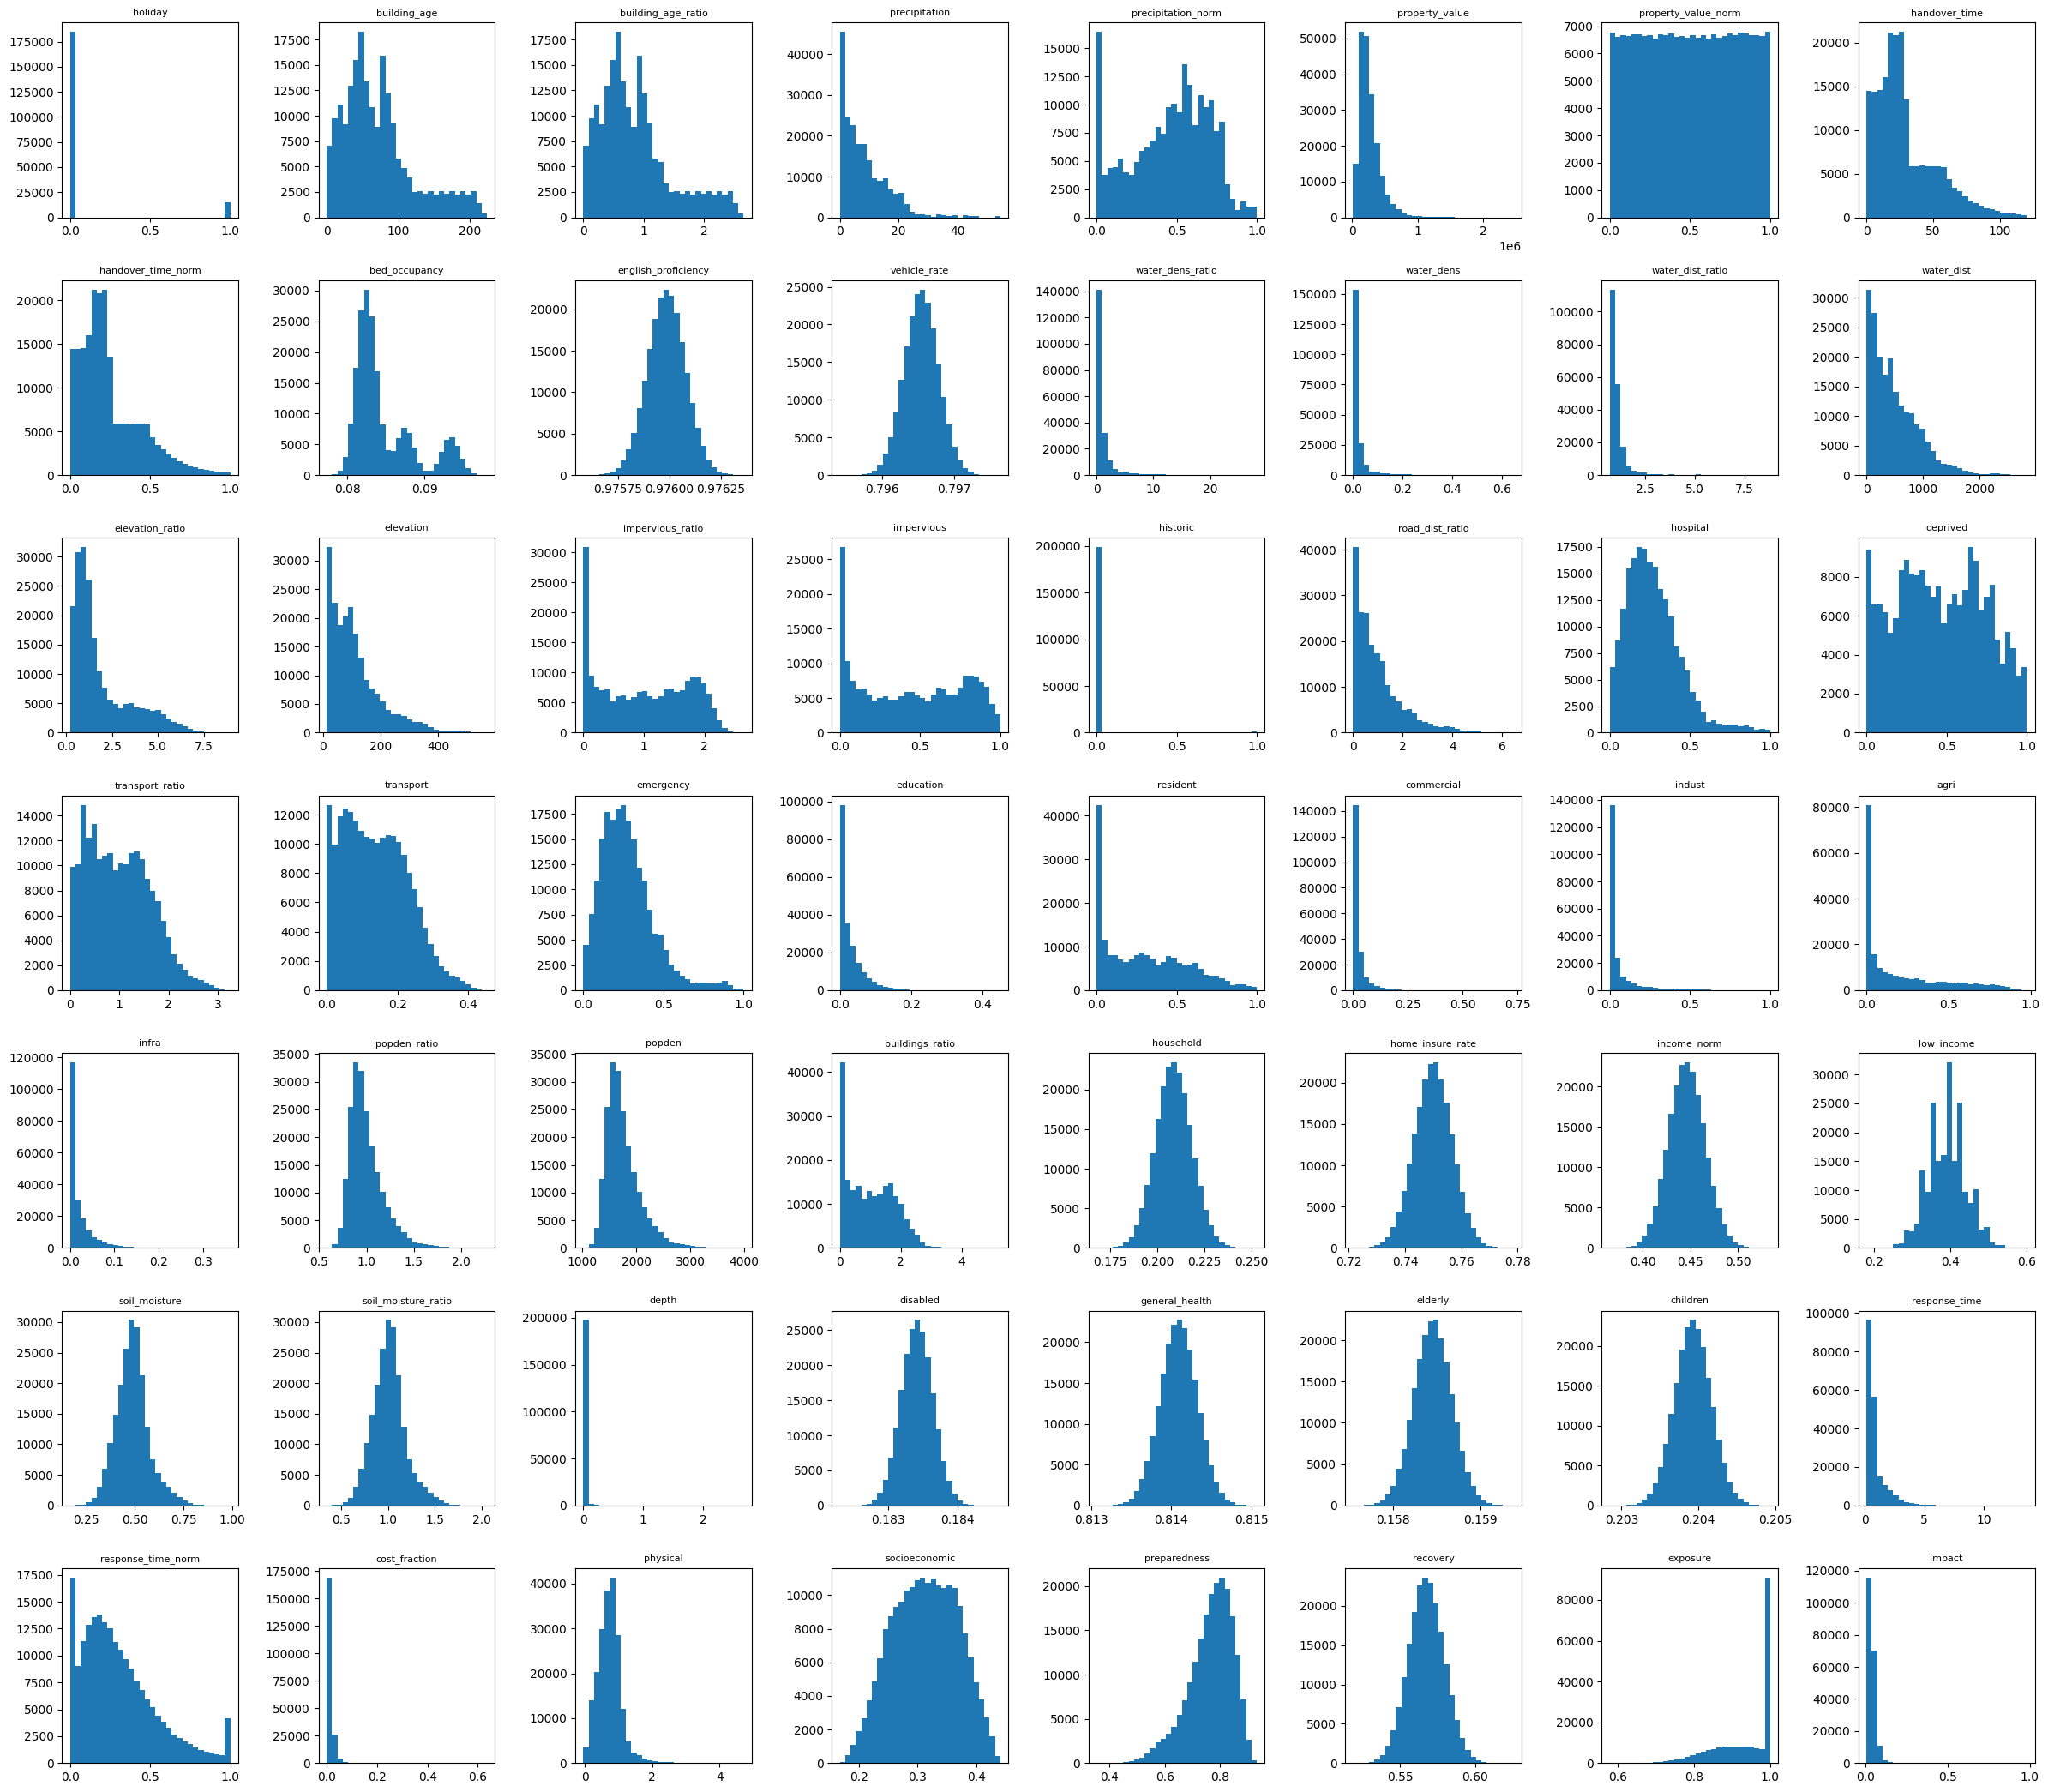

In [4]:
warning = "yellow"

df = pd.read_csv(f"warning/samples/{warning}_samples.csv")

n = len(df.columns)

ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
axes = axes.flatten()

for ax, col in zip(axes, df.columns):
    ax.hist(df[col].dropna(), bins=30)
    ax.set_title(col, fontsize=8)

# hide unused axes
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()